# DataProject: Proyecto EDA con Python

En este proyecto presento mi análisis exploratorio de datos (EDA) sobre campañas de marketing directo (llamadas telefónicas) de una institución bancaria. Mi objetivo principal es analizar de forma objetiva qué factores reales influyen en que un cliente se suscriba ("yes") o no a un depósito a plazo bancario.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual y de Pandas
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted") # Homogeneizamos el estilo de los gráficos

## 1. Carga de Datos
Comienzo cargando los dos conjuntos de datos: la información de la campaña bancaria (CSV) y los detalles demográficos y de comportamiento de los clientes (Excel).

In [41]:
# Carga de datos de la campaña
datos_banco = pd.read_csv("../data/raw/bank-additional.csv", index_col=0)

# Carga y concatenación de las hojas de Excel de clientes
xls = pd.ExcelFile("../data/raw/customer-details.xlsx")
dfs = []
for sheet in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet)
    dfs.append(df)
    
datos_clientes = pd.concat(dfs, ignore_index=True)

## 2. Limpieza y Transformación de Datos
He centralizado la lógica de limpieza en funciones para estructurar mi código. Las decisiones clave que he aplicado son:
1. **Numéricas**: He convertido los tipos de texto a numéricos reemplazando comas por puntos y he imputado nulos usando medidas robustas (mediana y media).
2. **Binarias (`default`, `housing`, `loan`)**: Para preservar su naturaleza binaria, he imputado los nulos con la moda (el valor más frecuente) en lugar de crear una categoría nueva.
3. **Categóricas**: He imputado los valores nulos con la etiqueta "desconocido" y las he transformado a tipo `category` para optimizar memoria.
4. **Fechas**: He convertido la columna de texto a formato `datetime` (mapeando los meses en español) y he extraído el mes, año y día de la semana para mi posterior análisis de estacionalidad.

In [42]:
def limpiar_bank(df):
    df = df.copy()
    
    # 1. Corrección de numéricas
    num_cols = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "."), errors="coerce")
        
    # 2. Imputación centralizada de numéricas
    imputaciones_num = {
        "age": df["age"].median(),
        "euribor3m": df["euribor3m"].median(),
        "cons.price.idx": df["cons.price.idx"].mean(),
        "cons.conf.idx": df["cons.conf.idx"].mean(),
        "nr.employed": df["nr.employed"].median()
    }
    for col, valor in imputaciones_num.items():
        df[col] = df[col].fillna(valor)
            
    # 3. Binarias: Imputar con la moda y mantener como numéricas/categóricas
    bin_cols = ["default", "housing", "loan"]
    for col in bin_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
        
    # 4. Categóricas: Imputar con "desconocido"
    cat_cols = ["job", "education", "marital"]
    for col in cat_cols:
        df[col] = df[col].fillna("desconocido")
        
    # 5. Tratamiento de fecha
    meses_es = {"enero": "01", "febrero": "02", "marzo": "03", "abril": "04", "mayo": "05", "junio": "06", 
                "julio": "07", "agosto": "08", "septiembre": "09", "octubre": "10", "noviembre": "11", "diciembre": "12"}
    
    def convertir_fecha(fecha):
        if pd.isna(fecha): return pd.NaT
        try:
            dia, mes, anio = fecha.split('-')
            return pd.to_datetime(f"{anio}-{meses_es[mes.lower()]}-{int(dia):02d}")
        except: return pd.NaT

    df["date"] = df["date"].apply(convertir_fecha)
    df = df.dropna(subset=["date"]) # Excluimos nulos de fecha para análisis temporal
    
    # Explotar variables temporales
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.day_name()
    
    # 6. Optimización de memoria (category)
    cols_to_category = ["job", "marital", "education", "contact", "poutcome", "y", "day_of_week"]
    for col in cols_to_category:
        df[col] = df[col].astype("category")
        
    return df

def limpiar_customers(df):
    df = df.copy()
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
    return df

# Aplicacion de las funciones de limpieza
datos_banco_clean = limpiar_bank(datos_banco)
datos_clientes_clean = limpiar_customers(datos_clientes)



In [43]:
import os

# Crea la carpeta processed si no existe
os.makedirs("../data/processed", exist_ok=True)

# Guarda CSV en processed
datos_banco.to_csv("../data/processed/bank_clean.csv", index=False)

# Guarda Excel en processed
datos_clientes.to_excel("../data/processed/customers_clean.xlsx", index=False)

print("Archivos guardados correctamente en data/processed ✅")

Archivos guardados correctamente en data/processed ✅


## 3. Unión de los Datasets (Merge)
He cruzado ambos datasets utilizando sus identificadores únicos (`id_` e `ID`). Tras el proceso, he verificado que no existan duplicados no deseados y he exportado el dataset final limpio para su uso.

In [44]:
# Realizo el cruce
df_final = datos_banco_clean.merge(
    datos_clientes_clean,
    left_on="id_",
    right_on="ID",
    how="inner"
)

# Comprobaciones post-merge
print(f"Filas antes del merge (banco): {datos_banco_clean.shape[0]}")
print(f"Filas resultantes tras el merge: {df_final.shape[0]}")
print(f"Match exacto (%): {(df_final.shape[0] / datos_banco_clean.shape[0]) * 100:.2f}%")
print(f"Duplicados en dataset final: {df_final.duplicated().sum()}")

# Guarda dataset final
os.makedirs("../data/processed", exist_ok=True)
df_final.to_csv("../data/processed/df_final_clean.csv", index=False)

Filas antes del merge (banco): 42752
Filas resultantes tras el merge: 42752
Match exacto (%): 100.00%
Duplicados en dataset final: 0


## 4. Análisis

### Distribución de la variable objetivo
**Análisis de resultados:** El gráfico muestra un desbalanceo extremo. Apenas un ~11% de los clientes contactados aceptan la oferta ("yes"), frente a un ~89% de rechazos. Esto me indica que la campaña actual es muy ineficiente a nivel global y justifica la necesidad de segmentar para encontrar los nichos rentables.

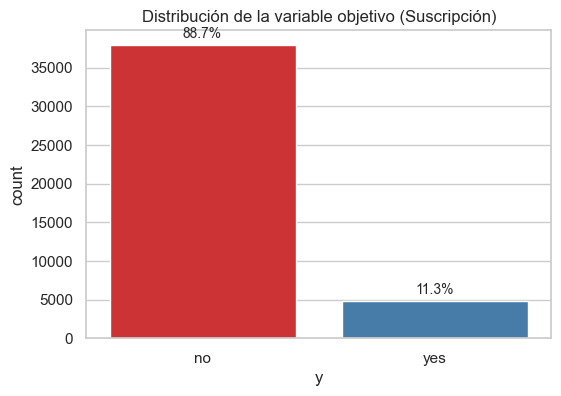

In [45]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df_final, x="y", hue="y", palette="Set1", legend=False)

plt.title("Distribución de la variable objetivo (Suscripción)")

# Añadir porcentajes
total = len(df_final)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 500), 
                ha='center', va='bottom', fontsize=10)
plt.show()

### Distribución de la Edad de los Clientes
**Análisis de resultados:** La distribución de edad de la base de clientes está claramente sesgada hacia la derecha. La inmensa mayoría de los esfuerzos del call center se concentran en clientes de entre 30 y 40 años. Las personas mayores de 60 años representan una porción minúscula de la base de contactos.

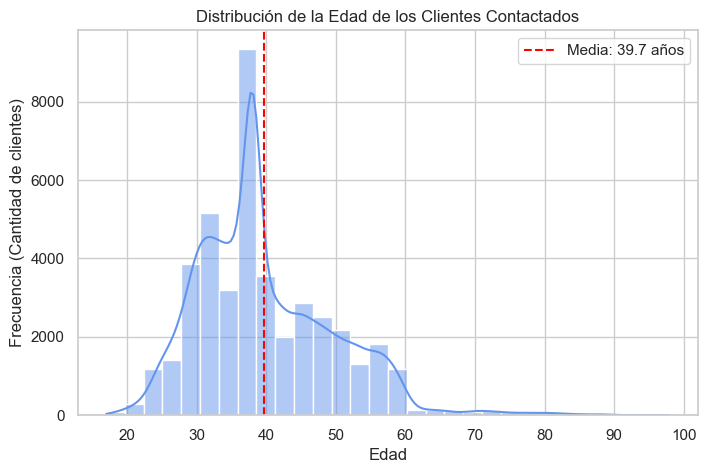

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_final, x="age", bins=30, kde=True, color="cornflowerblue")
plt.title("Distribución de la Edad de los Clientes Contactados")
plt.xlabel("Edad")
plt.ylabel("Frecuencia (Cantidad de clientes)")

# Añadimos una línea vertical para marcar la media de edad
media_edad = df_final["age"].mean()
plt.axvline(media_edad, color='red', linestyle='--', label=f'Media: {media_edad:.1f} años')
plt.legend()

plt.show()

### Perfil de Edad de los Clientes que SUSCRIBEN ("yes")
**Análisis de resultados:** Al observar exclusivamente a los clientes que SÍ compraron, la forma de la campana cambia ligeramente. Aunque el mayor volumen absoluto sigue estando entre los 30 y 40 años (por simple probabilidad, al ser los más llamados), la cola derecha "engorda". Esto demuestra visualmente que el subgrupo de personas mayores de 60 años, a pesar de ser poco contactado, tiene una tasa de aceptación proporcionalmente mucho más alta.

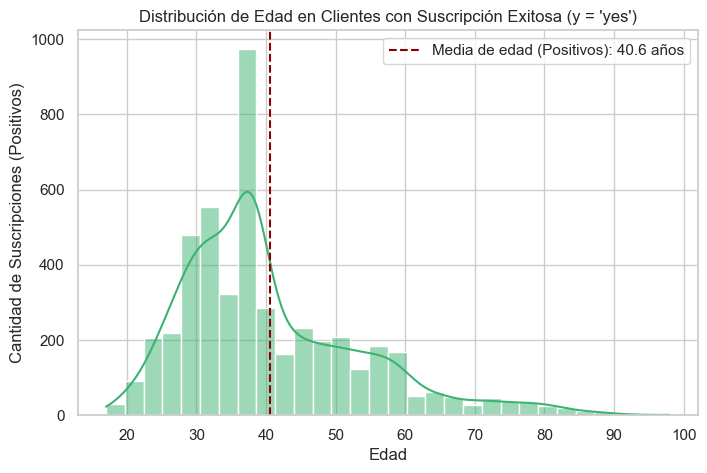

In [47]:
# Filtramos solo los casos positivos (suscripciones exitosas)
df_positivos = df_final[df_final["y"] == "yes"]

plt.figure(figsize=(8, 5))
sns.histplot(data=df_positivos, x="age", bins=30, kde=True, color="mediumseagreen")
plt.title("Distribución de Edad en Clientes con Suscripción Exitosa (y = 'yes')")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Suscripciones (Positivos)")

# Añadimos la media de edad de los que SÍ compran
media_edad_positivos = df_positivos["age"].mean()
plt.axvline(media_edad_positivos, color='darkred', linestyle='--', 
            label=f'Media de edad (Positivos): {media_edad_positivos:.1f} años')

plt.legend()
plt.show()

## 5. Análisis Segmentos

**Análisis de resultados:**
* **`poutcome` (Resultado previo):** Los datos son contundentes. Cuando un cliente ya aceptó una oferta en el pasado ("SUCCESS"), la probabilidad de que vuelva a decir que sí se multiplica drásticamente en comparación con aquellos cuyo contacto previo falló o no existió.
* **`job` (Profesión):** Las tasas relativas respaldan el insight de la edad: la categoría "retired" (jubilados) y "student" (estudiantes) lideran la conversión. Sin embargo, perfiles como "admin" o "blue-collar" son los que aportan el volumen bruto de ventas, aunque su tasa de éxito sea mucho más pobre.

In [48]:
# Función para analizar segmentos
def analisis_segmento(df, columna):
    segmento = df.groupby(columna, observed=False)["y"].value_counts(normalize=True).unstack()
    segmento["Tasa Exito (%)"] = segmento["yes"] * 100
    
    conteo = df[columna].value_counts()
    resumen = pd.DataFrame({"Tasa Exito (%)": segmento["Tasa Exito (%)"], "Tamaño Muestra": conteo})
    return resumen.sort_values(by="Tasa Exito (%)", ascending=False).dropna()

print("--- ANÁLISIS POR RESULTADO PREVIO (poutcome) ---")
display(analisis_segmento(df_final, "poutcome"))

print("\n--- ANÁLISIS POR PROFESIÓN (job) ---")
display(analisis_segmento(df_final, "job"))

--- ANÁLISIS POR RESULTADO PREVIO (poutcome) ---


,Tasa Exito (%),Tamaño Muestra
poutcome,,
SUCCESS,65.427770,1426
FAILURE,14.202116,4443
NONEXISTENT,8.803514,36883



--- ANÁLISIS POR PROFESIÓN (job) ---


,Tasa Exito (%),Tamaño Muestra
job,,
student,31.361607,896
retired,25.252525,1782
unemployed,14.447592,1059
admin.,12.979078,10802
desconocido,11.337209,344
management,11.133070,3036
self-employed,10.856372,1483
technician,10.839061,6984
housemaid,9.937332,1117


### Impacto de la Duración de la Llamada
**Análisis de resultados:** Al graficar la duración omitiendo los extremos, veo que la mediana de duración de las llamadas exitosas ("yes") es notablemente superior a las rechazadas. Las ventas requieren llamadas más largas. No obstante, asumo que esto es una consecuencia de la venta (explicar el contrato alarga la llamada) y no la causa inicial, por lo que no me servirá como predictor previo.

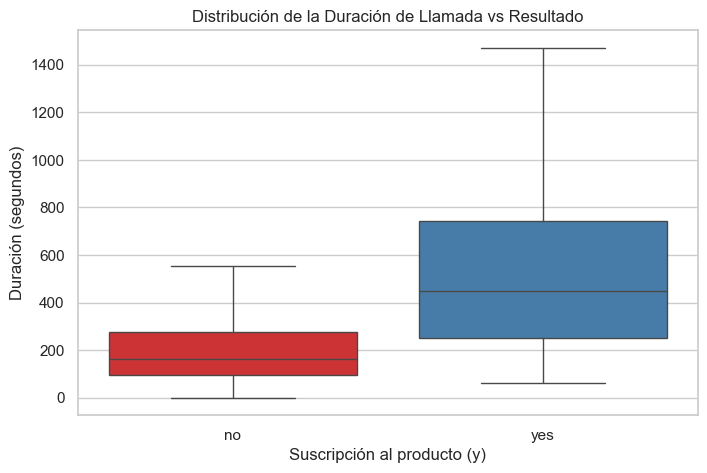

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_final, x="y", y="duration", hue="y", showfliers=False, palette="Set1", legend=False)

plt.title("Distribución de la Duración de Llamada vs Resultado")
plt.xlabel("Suscripción al producto (y)")
plt.ylabel("Duración (segundos)")

plt.show()

### Correlaciones y Segmentación de Clientes

**Análisis de resultados:**
* **Mapa de Calor:** Confirmo que las variables macroeconómicas (`euribor3m`, `emp.var.rate`, `nr.employed`) tienen correlaciones positivas altísimas entre sí (>0.90). El contexto económico influye en bloque sobre la disposición del cliente.
* **Edad vs Ingresos (`Income`):** A diferencia de lo que se podría hipotetizar, la dispersión de puntos revela que **no existe un clúster claro de ingresos** que determine el éxito. Los "yes" (puntos de otro color) están repartidos por todos los niveles salariales. Esto es un gran descubrimiento: el nivel de ingresos no es un factor determinante por sí solo para este producto, mientras que la edad sí influye de forma más transversal.

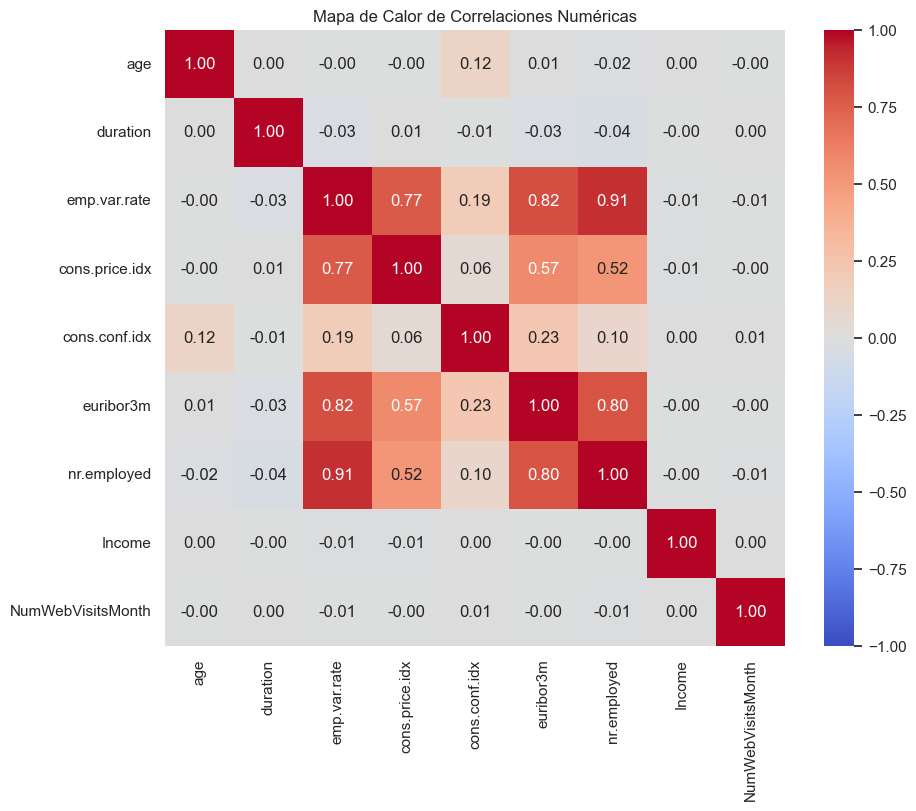

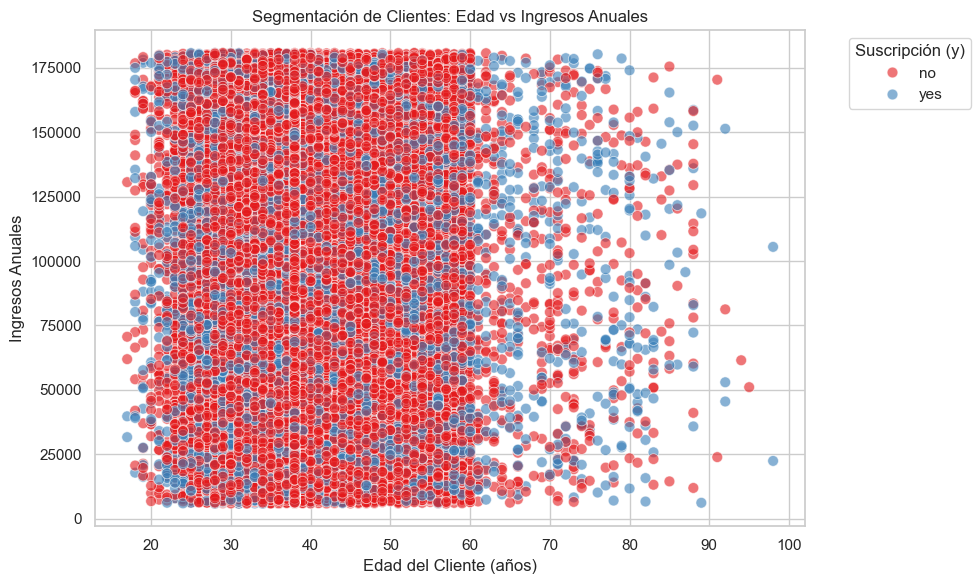

In [50]:
# Mapa de calor de correlaciones
num_cols_corr = ["age", "duration", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "Income", "NumWebVisitsMonth"]
corr_matrix = df_final[num_cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Mapa de Calor de Correlaciones Numéricas")
plt.show()

# Scatter plot: Edad vs Ingresos segmentado por resultado (y)
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_final, x='age', y='Income', hue='y', palette='Set1', alpha=0.6, s=60)

plt.title('Segmentación de Clientes: Edad vs Ingresos Anuales')
plt.xlabel('Edad del Cliente (años)')
plt.ylabel('Ingresos Anuales')

plt.legend(title='Suscripción (y)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Análisis de Estacionalidad: Mes y Día de la Semana

**Análisis de resultados:**
* **Análisis por Mes:** El gráfico refleja los meses más propicios para conseguir un mayor número de suscripciones al producto. Aunque la curva anual se mueve en un margen estrecho (entre un 10% y un 12%), observo que la actividad de este tipo de campaña se debe enfocar en la estacionalidad de verano (junio, julio y agosto) y en la recta final/inicio de año (octubre, noviembre, diciembre y enero). El resto de los meses pueden considerarse menos productivos, por lo que sugiero que los recursos en esas fechas se empleen en campañas diferentes o en promover otros productos.
* **Análisis por Día de la Semana:** Al observar la línea de tendencia de lunes a viernes, veo que es prácticamente plana (rondando el promedio del 11%). Concluyo de forma clara que el día de la semana es irrelevante para el éxito de la campaña.

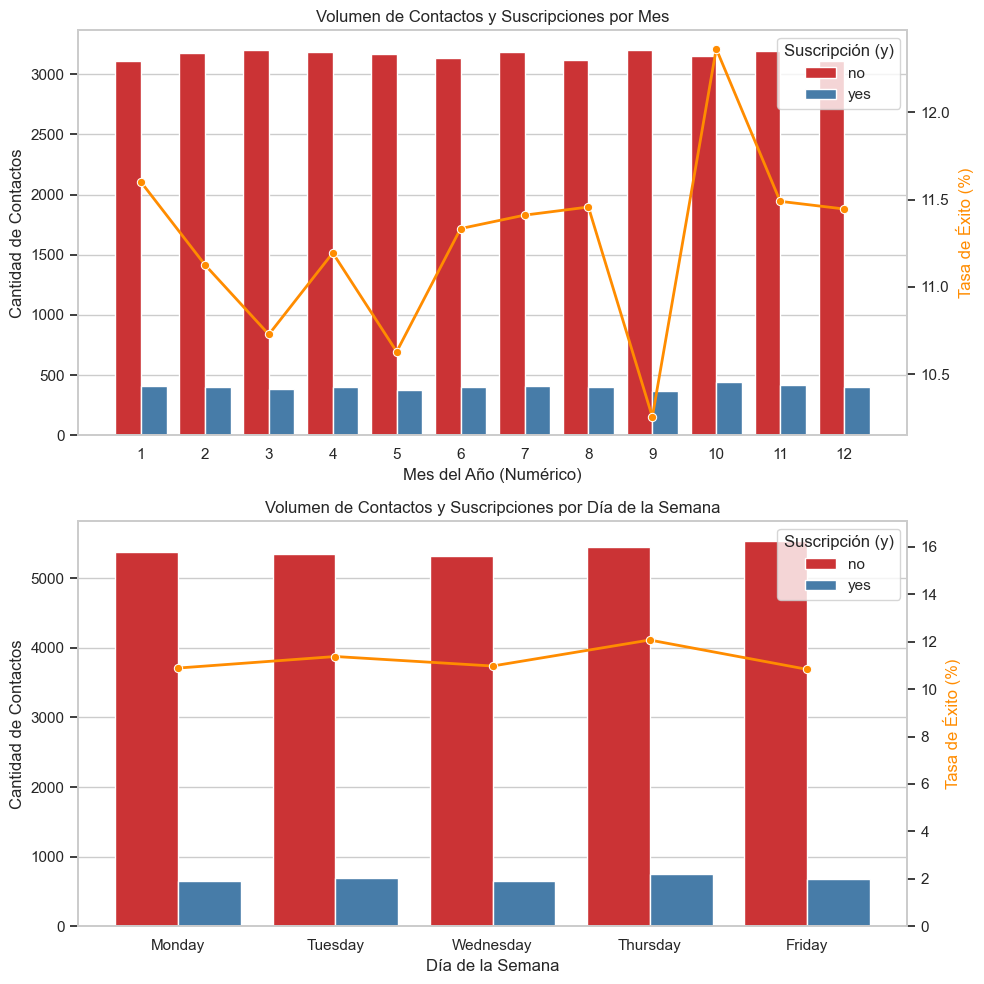

In [51]:
# --- GRÁFICOS DE ESTACIONALIDAD TEMPORAL ---
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Gráfico de Meses
# Calculamos la tasa de éxito por mes
tasa_mes = df_final.groupby('month', observed=False)['y'].apply(lambda x: (x == 'yes').mean() * 100).reset_index()

# Volumen de llamadas por mes
sns.countplot(data=df_final, x='month', hue='y', palette='Set1', ax=axes[0])
axes[0].set_title('Volumen de Contactos y Suscripciones por Mes', fontsize=12)
axes[0].set_xlabel('Mes del Año (Numérico)')
axes[0].set_ylabel('Cantidad de Contactos')
axes[0].legend(title='Suscripción (y)', loc='upper right')

# Añadimos una línea con la tasa de éxito en el mismo gráfico (eje gemelo)
ax0_twin = axes[0].twinx()
sns.lineplot(data=tasa_mes, x=tasa_mes.index, y='y', color='darkorange', marker='o', linewidth=2, ax=ax0_twin)
ax0_twin.set_ylabel('Tasa de Éxito (%)', color='darkorange')
ax0_twin.grid(False) # Quitamos la cuadrícula del eje gemelo para que no se superponga


# 2. Gráfico de Días de la Semana
# Ordenamos los días de lunes a viernes
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
tasa_dia = df_final.groupby('day_of_week', observed=False)['y'].apply(lambda x: (x == 'yes').mean() * 100).reindex(orden_dias).reset_index()

# Volumen de llamadas por día
sns.countplot(data=df_final, x='day_of_week', order=orden_dias, hue='y', palette='Set1', ax=axes[1])
axes[1].set_title('Volumen de Contactos y Suscripciones por Día de la Semana', fontsize=12)
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Cantidad de Contactos')
axes[1].legend(title='Suscripción (y)', loc='upper right')

# Añadimos la línea con la tasa de éxito
ax1_twin = axes[1].twinx()
sns.lineplot(data=tasa_dia, x=tasa_dia.index, y='y', color='darkorange', marker='o', linewidth=2, ax=ax1_twin)
ax1_twin.set_ylabel('Tasa de Éxito (%)', color='darkorange')
ax1_twin.set_ylim(0, max(tasa_dia['y']) + 5) # Damos un poco de aire al eje Y
ax1_twin.grid(False)

plt.tight_layout()
plt.show()

## 6. Conclusiones Finales

Tras la visualización objetiva y exhaustiva de los datos, estas son mis principales recomendaciones de negocio, fundamentadas en los *insights* clave extraídos durante este análisis:

1. **Cambio de modelo comercial (Calidad vs. Cantidad):** He comprobado que la estrategia actual de llamadas masivas y en frío es altamente ineficiente (apenas un ~11% de conversión global). El banco invierte la mayoría de sus recursos en llamar a un gran volumen de personas que no convierten, por lo que es vital transicionar hacia un modelo de segmentación precisa.
2. **Reenfoque Demográfico (Edad y Ocupación sobre Ingresos):** He demostrado que el nivel salarial de los clientes (`Income`) no es un factor determinante para vender este depósito. Sin embargo, la edad sí lo es. Recomiendo reducir drásticamente la intensidad de llamadas al grupo de 30 a 45 años (que acapara el esfuerzo comercial pero convierte poco) y enfocar la estrategia en perfiles con tasas de éxito significativamente mayores, concretamente los jubilados (mayores de 60 años) y los estudiantes.
3. **Prioridad Absoluta por Historial:** Todo cliente que haya respondido favorablemente en el pasado (`poutcome = SUCCESS`) debe encabezar indiscutiblemente la lista de la próxima campaña. Los datos confirman que su propensión a repetir la compra es excepcionalmente alta en comparación con el resto de la base de datos.
4. **Optimización Estacional:** Sugiero redistribuir estas campañas hacia el verano (junio, julio y agosto) y la recta final e inicio del año (octubre a enero), periodos donde la eficiencia es mas alta. Asimismo, la planificación puede ignorar el día de la semana, ya que he evidenciado que su impacto es totalmente nulo.
5. **Siguientes pasos analíticos:** Puesto que métricas como la duración de la llamada no se conocen a priori y no sirven para predecir, mi siguiente paso sería investigar el punto óptimo de contactos por cliente para evitar la "fatiga comercial" (el rechazo por insistencia).